### Figure 1 
subplot of 
- (a) hydrophone acoustic signal to obtain critical shear stress
- (b) example of Aich (2014) hysteresis calculations
- (c) hydrograph specific transport metrics example 

Note: Hex codes for viridis colors: 
- #440154 (Dark Purple / Violet)
- #3b528b (Deep Blue)
- #21918c (Teal)
- #5ec962 (Light Green)
- #fde725 (Yellow)

In [37]:
import numpy as np
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
import seaborn as sns

# import data 
shear_stress = pd.read_csv('../../data/shear_stress/average_total_shear_stress_corrected.csv', parse_dates=['datetime'], index_col='datetime')
dmax = pd.read_csv('st2_hydrophone_dmax.csv', parse_dates=['Time'], index_col='Time')

shear_stress = shear_stress.resample('1min').interpolate()
dmax = dmax.join(shear_stress, how="left")
# modify the specific dates 
dmax = dmax.loc['2022-08-03 13:00:00':'2022-08-03 21:00:00']


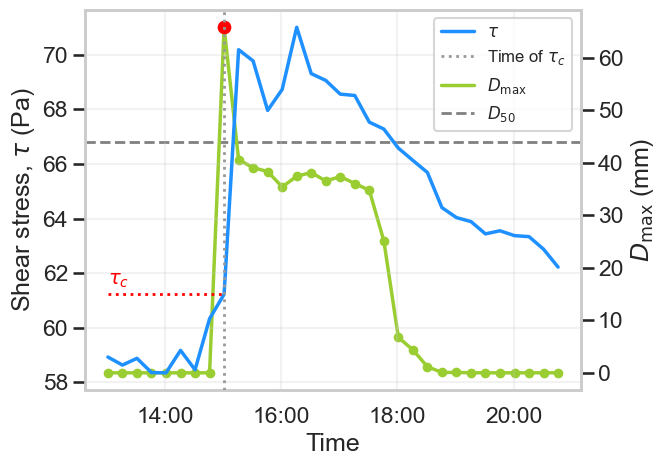

In [52]:
D50 = 44  # mm
sns.set_style("whitegrid")

fig, ax1 = plt.subplots(figsize=(7, 5))


ax1.plot(dmax.index, dmax["shear_stress"], color="dodgerblue", lw=2.5, label=r"$\tau$", zorder=5)
ax1.set_ylabel(r"Shear stress, $\tau$ (Pa)")
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax1.tick_params(axis="y")

ax2 = ax1.twinx()
ax2.plot(dmax.index, dmax["Dmax (mm)"], color="yellowgreen", lw=2.5, label=r"$D_{\max}$", zorder=5)
ax2.scatter(dmax.index, dmax["Dmax (mm)"], color="yellowgreen", s=30, zorder=5)
ax2.set_ylabel(r"$D_{\max}$ (mm)")
ax2.tick_params(axis="y")

ax2.axhline(D50, color="gray", ls="--", lw=2, label=r"$D_{50}$")

idx = dmax[dmax["Dmax (mm)"] >= D50].index[0]
tau_c = dmax.loc[idx, "shear_stress"]
ax2.scatter(idx, dmax.loc[idx, "Dmax (mm)"], color="red", s=70, zorder=5)

ax1.set_zorder(2)
ax2.set_zorder(1)

# Make ax1 background transparent so it doesn't hide ax2
ax1.patch.set_visible(False)

# annotate tau_c
#ax1.annotate(r"$\tau_c$", xy=(idx, tau_c), xytext=(-40,20), textcoords="offset points", color="red",
#    fontsize=14, arrowprops=dict(arrowstyle="->", color="red", lw=1.5), zorder=100)
#ax1.axhline(tau_c, xmin=0, xmax=ax1.get_xlim()[1], color="red", linestyle=":", linewidth=2, label=r"$\tau_c$")
xmin = dmax.index.min()
xmax = idx
ax1.hlines(tau_c, xmin=dmax.index[0], xmax=idx, color="red", linestyle=":", linewidth=2, zorder=10)
ax1.axvline(idx, color="0.6", linestyle=":", linewidth=2, label=r"Time of $\tau_c$", zorder=100)
ax1.text(dmax.index[0], tau_c+0.15, r"$\tau_c$", color="red", fontsize=14, va="bottom", zorder=100)
ax1.set_xlabel("Time")
ax1.grid(True, alpha=0.25)
ax2.grid(False)

# combined legend
lines = ax1.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, frameon=True, loc="upper right", fontsize=12)

plt.tight_layout()
plt.show()